In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.sqlite_version}")

All libraries imported successfully!
pandas version: 2.2.2
sqlite3 version: 3.37.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

df = pd.read_csv('/content/drive/MyDrive/internship/Copy of student_performance.csv')

In [ ]:
print(df.head(5))

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

In [ ]:
print("Row count:", df.shape[0])

Row count: 30


In [ ]:
print("Column count:", df.shape[1])

Column count: 13


In [ ]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(f"Database 'college.db' created successfully!")
print(f"Table 'students' has {count} rows")

Database 'college.db' created successfully!
Table 'students' has 30 rows


In [ ]:
cursor.execute("PRAGMA table_info(students)")
columns_info=cursor.fetchall()
print("Table structure of 'students':")
print(f"{'column Name':<25} {'Data Type':<12}")
print("-" * 38)
for col in columns_info:
  print(f"{col[1]:<25} {col[2]:<12}")

Table structure of 'students':
column Name               Data Type   
--------------------------------------
student_id                INTEGER     
name                      TEXT        
age                       INTEGER     
gender                    TEXT        
department                TEXT        
semester                  INTEGER     
math_score                INTEGER     
science_score             INTEGER     
english_score             INTEGER     
programming_score         INTEGER     
attendance_percentage     INTEGER     
city                      TEXT        
admission_year            INTEGER     


In [ ]:

def run_query(sql, description=""):

    if description:
        print(f"\n{'='*50}")
        print(description)
        print(f"{'='*50}")

    result = pd.read_sql_query(sql, conn)

    print(result.to_string(index=False))

    return result

print("Helper function 'run_query' defined successfully")
print("usage:run_query(sql_string,description_label)")

Helper function 'run_query' defined successfully
usage:run_query(sql_string,description_label)


In [ ]:
query1="""
select student_id,name,department,math_score,attendance_percentage from students Limit 10 """
result1=run_query(query1,"Query 1:First 10 students(SELECT + LIMIT)")


Query 1:First 10 students(SELECT + LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [ ]:
query1="""
select student_id,name,department,math_score,attendance_percentage from students  Limit 5 OFFSET 25 """
result1=run_query(query1,"Query 2:Last 5 students(SELECT + LIMIT)")


Query 2:Last 5 students(SELECT + LIMIT)
 student_id           name       department  math_score  attendance_percentage
       1026     Rekha Nair      Electronics          72                     82
       1027  Gaurav Shukla Computer Science          84                     87
       1028  Sunita Pillai            Civil          60                     73
       1029     Nitin Jain       Mechanical          75                     84
       1030 Akanksha Yadav Computer Science          91                     95


In [ ]:
query1="""
select name,department,math_score from students ORDER By math_score DESC Limit 5"""
result1=run_query(query1,"Query 3:Last 5 students(orderby + LIMIT)")


Query 3:Last 5 students(orderby + LIMIT)
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [ ]:
query1="""
select name,department,math_score from students ORDER By math_score  Limit 5"""
result1=run_query(query1,"Query 4:first 5 students(orderby + LIMIT)")


Query 4:first 5 students(orderby + LIMIT)
         name  department  math_score
 Manoj Pandey       Civil          56
  Meera Joshi Electronics          58
Sunita Pillai       Civil          60
 Sanjay Dubey       Civil          61
 Rahul Mishra  Mechanical          62


In [ ]:
query2="""
select name,department,programming_score from students ORDER By programming_score  Limit 5"""
result1=run_query(query2,"Query 5:first 5 students(orderby + LIMIT)")


Query 5:first 5 students(orderby + LIMIT)
         name department  programming_score
 Manoj Pandey      Civil                 38
Sunita Pillai      Civil                 39
  Kiran Kumar      Civil                 40
 Sanjay Dubey      Civil                 42
  Pooja Gupta      Civil                 44


In [ ]:
query2="""
select name,department,programming_score from students ORDER By programming_score DESC Limit 5"""
result1=run_query(query2,"Query 6:Last 5 students(orderby + LIMIT)")


Query 6:Last 5 students(orderby + LIMIT)
          name       department  programming_score
    Ananya Das Computer Science                 97
   Tanvi Mehta Computer Science                 96
    Arjun Nair Computer Science                 95
Akanksha Yadav Computer Science                 94
   Divya Singh Computer Science                 93


In [ ]:
query2="""
select name,department,programming_score from students
where programming_score between 50 AND 75 ORDER By programming_score DESC"""
result1=run_query(query2,"Query 7:students with programming score between 50 and 75")


Query 7:students with programming score between 50 and 75
         name  department  programming_score
  Vikram Iyer Electronics                 72
 Ritu Agarwal Electronics                 69
   Rekha Nair Electronics                 63
Harish Pillai Electronics                 58
  Rohit Verma Electronics                 55
Preeti Saxena  Mechanical                 53
  Meera Joshi Electronics                 52
Kavya Nambiar  Mechanical                 51
   Nitin Jain  Mechanical                 50


In [ ]:
query3="""
Select name,math_score,science_score,programming_score,attendance_percentage
from students
where department='Computer Science'
order by programming_score DESC"""
result1=run_query(query3,"Query 8:(select+where+orderby)")


Query 8:(select+where+orderby)
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor          79             84   

In [ ]:
query4="""
select DISTINCT department from students"""
result1=run_query(query4,"Query 9:(show the departments)")


Query 9:(show the departments)
Computer Science
     Electronics
      Mechanical
           Civil


In [ ]:
query4=""" SELECT department,
       MAX(math_score) AS highest_math_score
FROM students
WHERE department IN ('Computer Science', 'Electronics', 'Mechanical')
GROUP BY department
ORDER BY highest_math_score DESC
LIMIT 1;"""
result1=run_query(query4,"query 10:(select+where+in)")


query 10:(select+where+in)
Computer Science 95


In [ ]:
query4=""" select name,department,attendance_percentage
from students where attendance_percentage >90
AND department != 'Civil'
ORDER BY attendance_percentage DESC"""
result1=run_query(query4,"query 11:(select+where+oderby)")


query 11:(select+where+oderby)
    Ananya Das Computer Science 98
   Tanvi Mehta Computer Science 97
   Divya Singh Computer Science 96
   Sneha Reddy       Mechanical 95
Akanksha Yadav Computer Science 95
Swati Kulkarni Computer Science 94
  Ritu Agarwal      Electronics 93
  Aarav Sharma Computer Science 92
 Kavya Nambiar       Mechanical 91
     Amit Bose Computer Science 91


In [ ]:
query4=""" select name,department,attendance_percentage
from students where attendance_percentage > 80
AND attendance_percentage != 80
ORDER BY attendance_percentage DESC"""
result1=run_query(query4,"query 12:(select+where+oderby)")


query 12:(select+where+oderby)
    Ananya Das Computer Science 98
   Tanvi Mehta Computer Science 97
   Divya Singh Computer Science 96
   Sneha Reddy       Mechanical 95
Akanksha Yadav Computer Science 95
Swati Kulkarni Computer Science 94
  Ritu Agarwal      Electronics 93
  Aarav Sharma Computer Science 92
 Kavya Nambiar       Mechanical 91
     Amit Bose Computer Science 91
    Arjun Nair Computer Science 90
  Nisha Kapoor Computer Science 89
    Suresh Rao Computer Science 88
   Priya Patel Computer Science 87
 Gaurav Shukla Computer Science 87
 Preeti Saxena       Mechanical 86
   Kiran Kumar            Civil 85
    Nitin Jain       Mechanical 84
   Vikram Iyer      Electronics 83
    Rekha Nair      Electronics 82


In [ ]:
dept_data={
    'dept_code': ['cs','ec','mech','civil'],
    'dept_name': ['Computer Science','Electronics','Mechanical','civil'],
    'established':[1985,1988,1990,1992],
    'intake':    [60,60,80,90]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("Created 'departments' table:")
print(dept_df.to_string(index=False))
dept_map={
    'Computer Science':'cs',
    'Electronics':'ec',
    'Mechanical':'mech',
    'civil':'civil'
}
df['dept_code']=df['department'].map(dept_map)
df.to_sql('students',conn,if_exists='replace',index=False)
print("Updated")

Created 'departments' table:
dept_code        dept_name  established  intake
       cs Computer Science         1985      60
       ec      Electronics         1988      60
     mech       Mechanical         1990      80
    civil            civil         1992      90
Updated


In [ ]:
query_join="""
select s.name,
s.math_score,
d.dept_name,
d.intake,
d.established
from students AS s
inner join departments as d
on s.dept_code=d.dept_code
order by s.math_score DESC
limit 8
"""
result1=run_query(query_join,"query 13:(select+innerjoin+orderby)")


query 13:(select+innerjoin+orderby)
          name  math_score        dept_name  intake  established
    Ananya Das          95 Computer Science      60         1985
   Tanvi Mehta          93 Computer Science      60         1985
    Arjun Nair          92 Computer Science      60         1985
Akanksha Yadav          91 Computer Science      60         1985
Swati Kulkarni          90 Computer Science      60         1985
   Divya Singh          88 Computer Science      60         1985
  Ritu Agarwal          87      Electronics      60         1988
     Amit Bose          86 Computer Science      60         1985


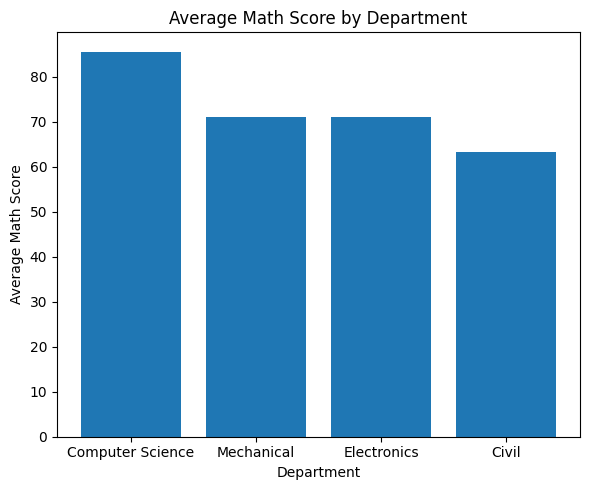

In [ ]:

chart1_sql = """
SELECT department,
       ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
chart1_data = pd.read_sql_query(chart1_sql, conn)
plt.figure(figsize=(6,5))

plt.bar(chart1_data['department'],
        chart1_data['avg_math'])
plt.title("Average Math Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Math Score")
plt.tight_layout()
plt.show()

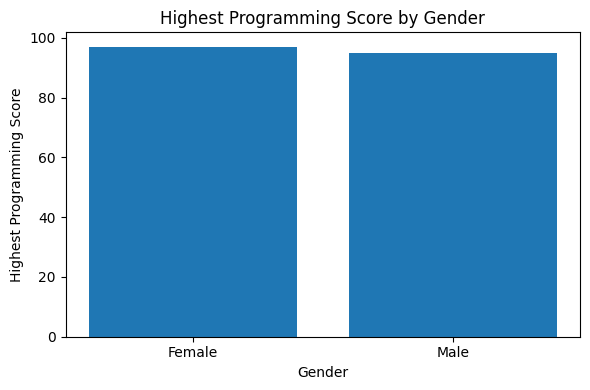

In [ ]:

query = """
SELECT gender,
       MAX(programming_score) AS highest_programming_score
FROM students
GROUP BY gender
ORDER BY highest_programming_score DESC
"""
chart_data = pd.read_sql_query(query, conn)

plt.figure(figsize=(6,4))

plt.bar(chart_data['gender'],
        chart_data['highest_programming_score'])
plt.title("Highest Programming Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Highest Programming Score")
plt.tight_layout()
plt.show()

In [ ]:
query = """
SELECT gender,
       MAX(programming_score) AS highest_programming_score
FROM students
GROUP BY gender
ORDER BY highest_programming_score DESC

"""

run_query(query, "Highest Programming Score by Gender")


Highest Programming Score by Gender
gender  highest_programming_score
Female                         97
  Male                         95


,gender,highest_programming_score
0,Female,97
1,Male,95
